# Regime-Shift: Macro-Aware Tactical Asset Allocation Engine

A regime-switching portfolio strategy that detects the market's hidden state (**Bull / Bear / Crisis**)
with a Hidden Markov Model, and reallocates between stocks, bonds, and gold using convex optimization
(`cvxpy`) — validated with **walk-forward backtesting** so results reflect only what was knowable in
real time (no lookahead bias).

**Pipeline:** data → features → regime detection (HMM) → regime-conditional optimization → walk-forward
backtest (with transaction costs) → comparison vs static 60/40 and equal-weight benchmarks.

Run all cells top to bottom. Section 1 needs internet access (pulls data via `yfinance`); if you're
offline, see the fallback cell at the end of Section 1.


## 0. Setup & Imports

In [5]:
!pip install cvxpy

  Using cached clarabel-0.11.1-cp39-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 12.0 MB/s  0:00:00
Using cached clarabel-0.11.1-cp39-abi3-win_amd64.whl (887 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------------------ --------- 2.1/2.7 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 9.8 MB/s  0:00:00
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
   ---------------------------------------- 0.0/7.5 MB ? eta -:--:--
   ------------ --------------------------- 2.4/7.5 MB 11.2 MB/s eta 0:00:01
   ----------------------- ---------------- 4.5/7.5 MB 10.7 MB/s eta 0:00:01
   ----------------------------------- ---- 6.6/7.5 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------- 7.5/7.5 MB 10.5 MB/s  0:00:0

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 11.3.0 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
import cvxpy as cp

np.random.seed(42)
pd.set_option("display.width", 120)


c:\Users\Bhavin\Downloads\Telegram Desktop\Lib\site-packages\numpy\_core\_dtype.py:106: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if dtype.type == np.bool:
(CVXPY) Jul 05 11:16:10 AM: Encountered unexpected exception importing solver MPAX:
TypeError("ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''")


## 1. Get and Understand Your Data

Pulls daily prices for stocks (Nifty ETF proxy), gold (Gold ETF proxy), a bond proxy, and the
India VIX (volatility / fear gauge), via `yfinance`.

**Note on the bond ticker:** NSE gilt/bond ETFs sometimes have short or patchy Yahoo Finance
history. If the download errors out on that leg, swap `TICKERS["bonds"]` below for
`"LICNETFGSEC.NS"` or `"SETFGILT.NS"` and re-run this cell.


In [9]:
TICKERS = {
    "stocks": "SPY",   # S&P 500 ETF
    "gold": "GLD",      # Gold ETF
    "bonds": "TLT",  # Gilt/long-bond ETF proxy (swap if history is too short)
}
VIX_TICKER = "^VIX"

def download_prices(start="2015-01-01", end=None, tickers=None, vix_ticker=VIX_TICKER):
    tickers = tickers or TICKERS
    all_symbols = list(tickers.values()) + [vix_ticker]
    raw = yf.download(all_symbols, start=start, end=end, progress=False, auto_adjust=True)
    close = raw["Close"].copy()
    close.columns.name = None

    rename_map = {v: k for k, v in tickers.items()}
    prices = close[list(tickers.values())].rename(columns=rename_map)
    vix = close[vix_ticker].rename("VIX")

    prices = prices.ffill().dropna()
    vix = vix.ffill().reindex(prices.index).dropna()

    common_idx = prices.index.intersection(vix.index)
    return prices.loc[common_idx], vix.loc[common_idx]

def to_log_returns(prices):
    return np.log(prices).diff().dropna()

prices, vix = download_prices()
print(prices.shape, "rows of aligned data")
prices.tail()


(2892, 3) rows of aligned data


,stocks,gold,bonds
Date,,,
2026-06-26,728.989990,373.630005,87.038544
2026-06-29,741.000000,368.579987,87.128204
2026-06-30,746.770020,368.380005,86.101997
2026-07-01,745.760010,370.600006,85.519997
2026-07-02,744.780029,378.130005,85.510002


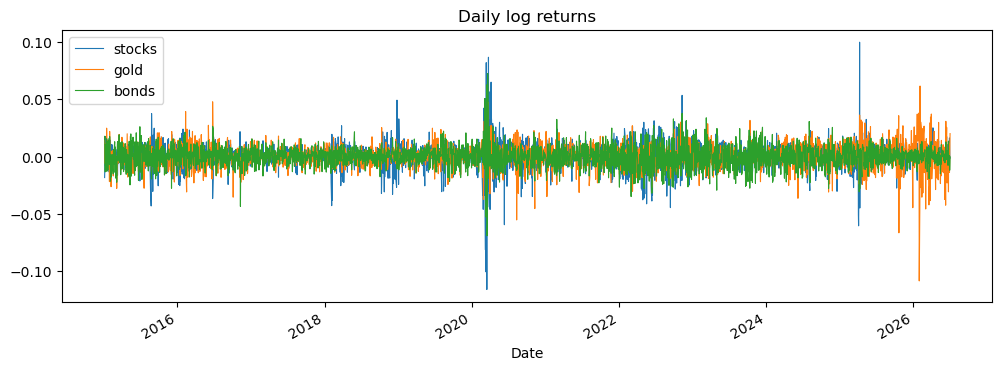

In [10]:
# Quick look at raw returns before doing anything clever
asset_log_returns = to_log_returns(prices)
asset_log_returns.plot(figsize=(12, 4), title="Daily log returns", lw=0.8)
plt.show()


**Offline fallback:** if you have no internet access in this environment, run the cell below
instead of the one above to generate a synthetic-but-realistic regime-switching dataset, so the
rest of the notebook still runs end to end. Skip it if `download_prices()` worked.

In [11]:
# --- OFFLINE FALLBACK (only run this if download_prices() above failed) ---
USE_SYNTHETIC_FALLBACK = False

if USE_SYNTHETIC_FALLBACK:
    n = 1600
    dates = pd.bdate_range("2017-01-01", periods=n)
    regimes = np.zeros(n, dtype=int)
    i = 0
    while i < n:
        length = np.random.randint(60, 200)
        r = np.random.choice([0, 1, 2], p=[0.55, 0.3, 0.15])
        regimes[i:i+length] = r
        i += length
    mu_map = {0: 0.0006, 1: -0.0003, 2: -0.002}
    sig_map = {0: 0.008, 1: 0.012, 2: 0.035}
    stock_ret = np.array([np.random.normal(mu_map[r], sig_map[r]) for r in regimes])
    bond_ret = np.random.normal(0.0001, 0.003, n) - 0.015 * stock_ret
    gold_ret = np.random.normal(0.0002, 0.006, n) + 0.001 * (regimes == 2)
    prices = pd.DataFrame({
        "stocks": 100 * np.exp(np.cumsum(stock_ret)),
        "bonds": 100 * np.exp(np.cumsum(bond_ret)),
        "gold": 100 * np.exp(np.cumsum(gold_ret)),
    }, index=dates)
    vix = pd.Series(12 + 40*(regimes==2) + 15*(regimes==1) + np.random.normal(0,1.5,n),
                     index=dates, name="VIX").clip(8, None)
    print("Synthetic fallback data generated:", prices.shape)


## 2. Engineer Features That Describe the Market's State

- **Momentum** (21d, 63d rolling % change) — direction.
- **Volatility** (21d, 63d rolling annualized std of returns) — the single most reliable crisis signal.
- **India VIX level & 5-day change** — a market-implied fear gauge.

All computed with `.rolling()` / `.pct_change()` only — nothing here uses full-sample statistics,
which is the first line of defense against lookahead bias.


In [12]:
MOM_WINDOWS = [21, 63]
VOL_WINDOWS = [21, 63]

def build_features(prices, vix, market_col="stocks"):
    log_ret = np.log(prices[market_col]).diff()
    feat = pd.DataFrame(index=prices.index)
    for w in MOM_WINDOWS:
        feat[f"mom_{w}"] = prices[market_col].pct_change(w)
    for w in VOL_WINDOWS:
        feat[f"vol_{w}"] = log_ret.rolling(w).std() * np.sqrt(252)
    feat["vix_level"] = vix
    feat["vix_chg_5d"] = vix.pct_change(5)
    return feat.dropna()

def expanding_zscore_fit(train_feat):
    mu = train_feat.mean()
    sigma = train_feat.std().replace(0, 1e-8)
    return mu, sigma

def apply_zscore(feat, mu, sigma):
    return (feat - mu) / sigma

feat_raw = build_features(prices, vix)
feat_raw.tail()


,mom_21,mom_63,vol_21,vol_63,vix_level,vix_chg_5d
Date,,,,,,
2026-06-26,-0.026107,0.152625,0.167417,0.144380,18.410000,0.122561
2026-06-29,-0.015493,0.175545,0.176876,0.146627,17.650000,0.021412
2026-06-30,-0.010293,0.151235,0.179017,0.137168,16.450001,-0.155977
2026-07-01,-0.014315,0.141080,0.178652,0.136928,16.590000,-0.109501
2026-07-02,-0.016945,0.138555,0.178506,0.137078,16.150000,-0.145050


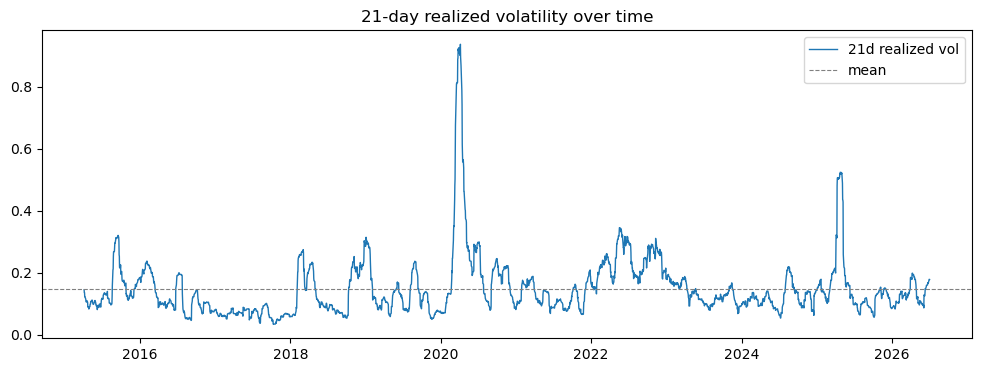

In [13]:
# Sanity-check: does volatility spike where we'd expect (known turbulent periods)?
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(feat_raw.index, feat_raw["vol_21"], label="21d realized vol", lw=1)
ax.axhline(feat_raw["vol_21"].mean(), color="grey", ls="--", lw=0.8, label="mean")
ax.set_title("21-day realized volatility over time")
ax.legend()
plt.show()


## 3. Build the Regime Classifier (Hidden Markov Model)

Fits a Gaussian HMM with 3 hidden states to the (scaled) feature matrix, then labels the arbitrary
state indices as Bull / Bear / Crisis using each state's average volatility and momentum
(highest-vol state -> Crisis; of the rest, higher-momentum state -> Bull).

This section fits on the **full dataset once**, purely so you can see what a "wow it's working"
regime chart looks like. The walk-forward backtest in Section 5 refits the HMM properly inside
each training window only — that full-sample fit here is for illustration and is not used in the backtest.


In [14]:
N_STATES = 3

def fit_hmm(X, n_states=N_STATES, n_iter=200, random_state=42):
    model = GaussianHMM(n_components=n_states, covariance_type="diag",
                         n_iter=n_iter, random_state=random_state)
    model.fit(X)
    return model

def label_states(feat_scaled, states):
    df = feat_scaled.copy()
    df["state"] = states
    vol_col = [c for c in df.columns if c.startswith("vol_")][0]
    mom_col = [c for c in df.columns if c.startswith("mom_")][0]
    state_vol = df.groupby("state")[vol_col].mean().sort_values(ascending=False)
    crisis_state = state_vol.index[0]
    remaining = [s for s in state_vol.index if s != crisis_state]
    state_mom = df.groupby("state")[mom_col].mean()
    remaining_sorted = sorted(remaining, key=lambda s: state_mom[s], reverse=True)
    bull_state, bear_state = remaining_sorted[0], remaining_sorted[1]
    return {crisis_state: "Crisis", bull_state: "Bull", bear_state: "Bear"}

# Illustrative full-sample fit (NOT used in the walk-forward backtest below)
mu_full, sigma_full = expanding_zscore_fit(feat_raw)
feat_scaled_full = apply_zscore(feat_raw, mu_full, sigma_full)
illustrative_model = fit_hmm(feat_scaled_full.values)
illustrative_states = illustrative_model.predict(feat_scaled_full.values)
label_map = label_states(feat_scaled_full, illustrative_states)
illustrative_labels = pd.Series([label_map[s] for s in illustrative_states], index=feat_raw.index)

print("Transition matrix (rows=from, cols=to):")
print(np.round(illustrative_model.transmat_, 3))
illustrative_labels.value_counts()


Transition matrix (rows=from, cols=to):
[[0.007 0.968 0.025]
 [0.937 0.062 0.   ]
 [0.024 0.    0.976]]


Crisis    952
Bear      950
Bull      927
Name: count, dtype: int64

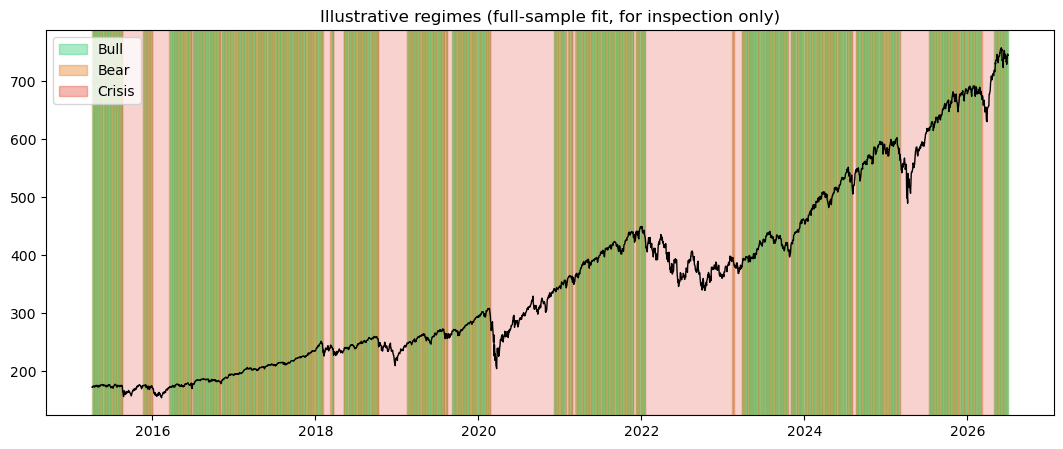

In [15]:
# First "wow it's working" checkpoint: price chart with regimes overlaid
REGIME_COLORS = {"Bull": "#2ecc71", "Bear": "#e67e22", "Crisis": "#e74c3c"}

def plot_regimes(price_series, regime_labels, title):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(price_series.index, price_series.values, color="black", lw=1.0)
    ax.set_title(title)
    start = regime_labels.index[0]
    current = regime_labels.iloc[0]
    for i in range(1, len(regime_labels)):
        if regime_labels.iloc[i] != current or i == len(regime_labels) - 1:
            end = regime_labels.index[i]
            ax.axvspan(start, end, color=REGIME_COLORS.get(current, "grey"), alpha=0.25)
            start = regime_labels.index[i]
            current = regime_labels.iloc[i]
    handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.4) for c in REGIME_COLORS.values()]
    ax.legend(handles, REGIME_COLORS.keys(), loc="upper left")
    plt.show()

plot_regimes(prices.loc[feat_raw.index, "stocks"], illustrative_labels,
             "Illustrative regimes (full-sample fit, for inspection only)")


## 4. Connect Regimes to Portfolio Decisions (Convex Optimization)

Each regime maps to a different `cvxpy` objective, long-only and fully invested:

| Regime | Objective |
|---|---|
| Bull | Maximize `mu^T w - gamma * w^T Sigma w`, low `gamma` (tilts toward return) |
| Bear | Same objective, moderate `gamma` (balanced) |
| Crisis | Pure minimum-variance (expected-return estimates are least reliable exactly when they matter most) |


In [16]:
REGIME_RISK_AVERSION = {"Bull": 1.0, "Bear": 5.0, "Crisis": 25.0}
MAX_WEIGHT = 0.7

def optimal_weights(mu, sigma, regime):
    n = len(mu)
    w = cp.Variable(n)
    gamma = REGIME_RISK_AVERSION.get(regime, 5.0)
    if regime == "Crisis":
        objective = cp.Minimize(cp.quad_form(w, sigma))
    else:
        objective = cp.Maximize(mu @ w - gamma * cp.quad_form(w, sigma))
    constraints = [cp.sum(w) == 1, w >= 0, w <= MAX_WEIGHT]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP, verbose=False)
    if w.value is None:
        return np.ones(n) / n
    weights = np.clip(w.value, 0, None)
    return weights / weights.sum()

# Quick illustration on the full-sample data
asset_cols = ["stocks", "bonds", "gold"]
demo_returns = to_log_returns(prices)[asset_cols]
demo_mu = demo_returns.mean().values * 252
demo_sigma = demo_returns.cov().values * 252 + np.eye(3) * 1e-6
for regime in ["Bull", "Bear", "Crisis"]:
    w = optimal_weights(demo_mu, demo_sigma, regime)
    print(f"{regime:7s} -> " + ", ".join(f"{c}: {v:.1%}" for c, v in zip(asset_cols, w)))


Bull    -> stocks: 67.9%, bonds: 0.0%, gold: 32.1%
Bear    -> stocks: 48.0%, bonds: 6.1%, gold: 45.9%
Crisis  -> stocks: 34.3%, bonds: 42.6%, gold: 23.1%


## 5. Performance Metrics (Sharpe, Sortino, Max Drawdown, Calmar, Turnover)

In [17]:
TRADING_DAYS = 252

def sharpe_ratio(returns, rf=0.0):
    excess = returns - rf / TRADING_DAYS
    return 0.0 if excess.std() == 0 else np.sqrt(TRADING_DAYS) * excess.mean() / excess.std()

def sortino_ratio(returns, rf=0.0):
    excess = returns - rf / TRADING_DAYS
    downside = excess[excess < 0]
    denom = downside.std()
    return 0.0 if denom == 0 or np.isnan(denom) else np.sqrt(TRADING_DAYS) * excess.mean() / denom

def max_drawdown(equity_curve):
    running_max = equity_curve.cummax()
    return (equity_curve / running_max - 1).min()

def calmar_ratio(returns, equity_curve):
    ann_return = (equity_curve.iloc[-1] ** (TRADING_DAYS / len(returns))) - 1
    mdd = abs(max_drawdown(equity_curve))
    return 0.0 if mdd == 0 else ann_return / mdd

def turnover(weights_history):
    return weights_history.diff().abs().sum(axis=1).div(2).mean()

def performance_summary(name, returns, weights_history=None):
    equity_curve = (1 + returns).cumprod()
    summary = {
        "Strategy": name,
        "Total Return %": (equity_curve.iloc[-1] - 1) * 100,
        "Ann. Return %": ((equity_curve.iloc[-1] ** (TRADING_DAYS / len(returns))) - 1) * 100,
        "Ann. Vol %": returns.std() * np.sqrt(TRADING_DAYS) * 100,
        "Sharpe": sharpe_ratio(returns),
        "Sortino": sortino_ratio(returns),
        "Max Drawdown %": max_drawdown(equity_curve) * 100,
        "Calmar": calmar_ratio(returns, equity_curve),
    }
    if weights_history is not None:
        summary["Avg Daily Turnover %"] = turnover(weights_history) * 100
    return summary


## 6. Walk-Forward Validation + Regime-Driven Backtest

This is the part of the project that actually proves the strategy isn't cheating:

1. **Expanding walk-forward splits** — train window grows, test window slides forward 6 months at a time.
2. **HMM + z-score scaler refit inside each training window only**, then applied (never refit) to that window's test segment.
3. Portfolio weights for day *t* are optimized using mean/covariance estimated from the trailing 252 days **ending before** *t* — re-optimized only when the detected regime changes (which is also what makes transaction-cost modeling meaningful).
4. A 5–10 bps transaction cost is charged on every rebalance.
5. Benchmarked against static 60/40 and equal-weight over the identical out-of-sample dates.


In [18]:
TXN_COST_BPS = 7.5
LOOKBACK_DAYS = 252

def expanding_walk_forward_splits(n_obs, n_splits=6, min_train_size=750, test_size=126):
    splits = []
    start_test = min_train_size
    for _ in range(n_splits):
        end_test = start_test + test_size
        if end_test > n_obs:
            break
        splits.append((np.arange(0, start_test), np.arange(start_test, end_test)))
        start_test = end_test
    return splits

def estimate_mu_sigma(asset_returns, as_of_idx, lookback=LOOKBACK_DAYS):
    start = max(0, as_of_idx - lookback)
    window = asset_returns.iloc[start:as_of_idx]
    mu = window.mean().values * 252
    sigma = window.cov().values * 252 + np.eye(window.shape[1]) * 1e-6
    return mu, sigma

def run_walk_forward_backtest(prices, vix, asset_cols=("stocks", "bonds", "gold")):
    asset_cols = list(asset_cols)
    asset_returns = np.log(prices[asset_cols]).diff().dropna()
    feat_raw_ = build_features(prices, vix, market_col="stocks")

    common_idx = feat_raw_.index.intersection(asset_returns.index)
    feat_raw_ = feat_raw_.loc[common_idx]
    asset_returns = asset_returns.loc[common_idx]
    prices_aligned = prices.loc[common_idx]

    n_obs = len(feat_raw_)
    splits = expanding_walk_forward_splits(n_obs)
    if not splits:
        raise ValueError("Not enough history for the requested walk-forward window sizes.")

    all_regime_labels = pd.Series(index=feat_raw_.index, dtype=object)
    strategy_returns = pd.Series(index=feat_raw_.index, dtype=float)
    weights_history = pd.DataFrame(index=feat_raw_.index, columns=asset_cols, dtype=float)
    last_transition_matrix = None
    pos_map = {d: i for i, d in enumerate(feat_raw_.index)}

    for train_idx, test_idx in splits:
        train_feat = feat_raw_.iloc[train_idx]
        test_feat = feat_raw_.iloc[test_idx]

        mu_scale, sigma_scale = expanding_zscore_fit(train_feat)
        train_scaled = apply_zscore(train_feat, mu_scale, sigma_scale)
        test_scaled = apply_zscore(test_feat, mu_scale, sigma_scale)

        model = fit_hmm(train_scaled.values)
        train_states = model.predict(train_scaled.values)
        state_label_map = label_states(train_scaled, train_states)
        last_transition_matrix = model.transmat_

        test_states = model.predict(test_scaled.values)
        test_labels = pd.Series([state_label_map.get(s, "Bear") for s in test_states], index=test_feat.index)
        all_regime_labels.loc[test_labels.index] = test_labels.values

        current_regime, current_weights = None, None
        for date in test_feat.index:
            i = pos_map[date]
            regime = test_labels.loc[date]
            rebalanced_today = False
            if regime != current_regime or current_weights is None:
                mu, sigma = estimate_mu_sigma(asset_returns, i)
                new_weights = optimal_weights(mu, sigma, regime)
                if current_weights is not None:
                    cost = TXN_COST_BPS / 1e4 * np.abs(new_weights - current_weights).sum() / 2
                else:
                    cost = TXN_COST_BPS / 1e4
                rebalanced_today = True
                current_weights, current_regime = new_weights, regime
            else:
                cost = 0.0
            day_return = float(np.dot(current_weights, asset_returns.loc[date, asset_cols].values))
            strategy_returns.loc[date] = day_return - (cost if rebalanced_today else 0.0)
            weights_history.loc[date] = current_weights

    strategy_returns = strategy_returns.dropna()
    weights_history = weights_history.dropna()
    all_regime_labels = all_regime_labels.dropna()

    oos_idx = strategy_returns.index
    bench_returns = asset_returns.loc[oos_idx, asset_cols]

    static_w_vec = np.array([0.6 if c == "stocks" else 0.4 if c == "bonds" else 0.0 for c in asset_cols])
    static_returns = pd.Series(bench_returns.values @ static_w_vec, index=oos_idx)

    eq_w_vec = np.ones(len(asset_cols)) / len(asset_cols)
    eq_returns = pd.Series(bench_returns.values @ eq_w_vec, index=oos_idx)

    return {
        "regime_labels": all_regime_labels,
        "strategy_returns": strategy_returns,
        "weights_history": weights_history,
        "static_60_40_returns": static_returns,
        "equal_weight_returns": eq_returns,
        "transition_matrix": last_transition_matrix,
        "prices_aligned": prices_aligned.loc[oos_idx],
    }

def summarize_results(results):
    rows = [
        performance_summary("HMM Regime-Switching (net of costs)", results["strategy_returns"], results["weights_history"]),
        performance_summary("Static 60/40", results["static_60_40_returns"]),
        performance_summary("Equal-Weight", results["equal_weight_returns"]),
    ]
    return pd.DataFrame(rows).set_index("Strategy")

results = run_walk_forward_backtest(prices, vix)
summary = summarize_results(results)
summary.round(3)


c:\Users\Bhavin\Downloads\Telegram Desktop\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Bhavin\Downloads\Telegram Desktop\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Bhavin\Downloads\Telegram Desktop\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Bhavin\Downloads\Telegram Desktop\Lib\site-packages\sklearn\cluster\_kmea

,Total Return %,Ann. Return %,Ann. Vol %,Sharpe,Sortino,Max Drawdown %,Calmar,Avg Daily Turnover %
Strategy,,,,,,,,
HMM Regime-Switching (net of costs),21.113,6.593,10.834,0.644,0.701,-17.273,0.382,1.106
Static 60/40,38.961,11.591,12.367,0.949,1.041,-19.543,0.593,NaN
Equal-Weight,32.516,9.839,9.671,1.019,1.206,-14.814,0.664,NaN


## 7. Results: Regime Chart, Equity Curves, and Transition Matrix

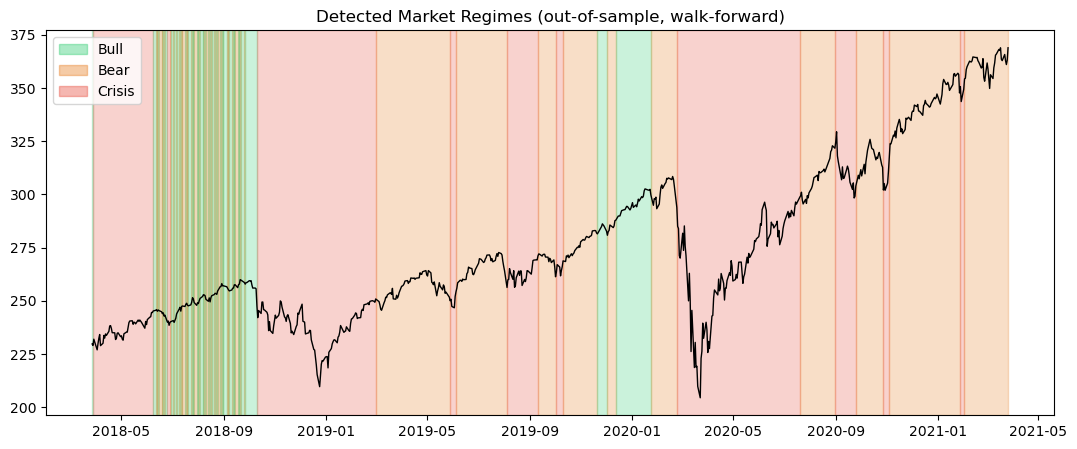

In [19]:
plot_regimes(results["prices_aligned"]["stocks"], results["regime_labels"],
             "Detected Market Regimes (out-of-sample, walk-forward)")


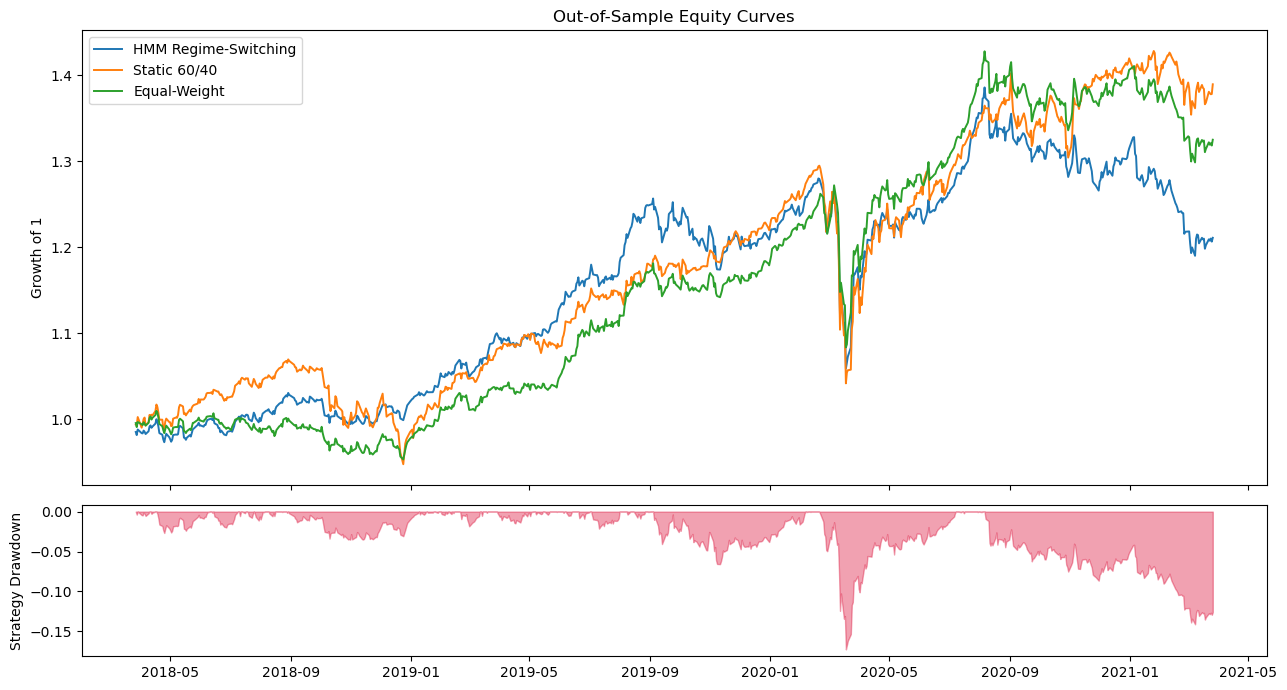

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
curves = {
    "HMM Regime-Switching": results["strategy_returns"],
    "Static 60/40": results["static_60_40_returns"],
    "Equal-Weight": results["equal_weight_returns"],
}
for name, r in curves.items():
    eq = (1 + r).cumprod()
    axes[0].plot(eq.index, eq.values, label=name, lw=1.4)
axes[0].set_title("Out-of-Sample Equity Curves")
axes[0].legend()
axes[0].set_ylabel("Growth of 1")

strat_eq = (1 + results["strategy_returns"]).cumprod()
dd = strat_eq / strat_eq.cummax() - 1
axes[1].fill_between(dd.index, dd.values, 0, color="crimson", alpha=0.4)
axes[1].set_ylabel("Strategy Drawdown")
plt.tight_layout()
plt.show()


In [21]:
print("Regime transition matrix (last walk-forward fold, rows=from, cols=to):")
pd.DataFrame(results["transition_matrix"],
             index=[f"from_state_{i}" for i in range(results['transition_matrix'].shape[0])],
             columns=[f"to_state_{i}" for i in range(results['transition_matrix'].shape[0])]).round(3)


Regime transition matrix (last walk-forward fold, rows=from, cols=to):


,to_state_0,to_state_1,to_state_2
from_state_0,0.986,0.000,0.014
from_state_1,0.000,0.966,0.034
from_state_2,0.019,0.007,0.974


In [22]:
print("Regime distribution over the out-of-sample period:")
results["regime_labels"].value_counts()


Regime distribution over the out-of-sample period:


Bear      361
Crisis    315
Bull       80
Name: count, dtype: int64

## 8. Key Decisions & Notes (for your GitHub README)

**Why 3 regimes?** Maps directly onto the optimizer's three objective functions
(max-Sharpe / balanced / min-variance). More states start splitting "Bear" into
statistically-real-but-not-actionable sub-states; fewer than 3 can't separate ordinary
drawdowns from true crises.

**Why these features?** Momentum captures direction; realized volatility is the most
reliable crisis signal in practice; India VIX level + 5-day change add a market-implied
fear gauge that price-based features alone tend to lag.

**How lookahead bias is avoided (the hard part of this project):**
1. Feature construction only uses `.rolling()` / `.pct_change()` — no full-sample stats.
2. Z-scoring is fit fresh inside every walk-forward training window, applied (never refit) to that window's test segment.
3. The HMM is refit from scratch inside each training window — it never sees test-period data while fitting.
4. Portfolio weights for day *t* use mean/covariance estimated from the trailing 252 days *ending before t*.
5. Every regime-change rebalance pays a 5–10 bps transaction cost, so reported Sharpe/Calmar are net of trading friction.

**Reproducibility:** the HMM uses `random_state=42`; given the same date range and tickers,
re-running this notebook top to bottom reproduces the same regime labels, weights, and
performance table.
